In [69]:
# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload
# %matplotlib widget

# os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import lib.decoder as decoder 

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np


from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import torch

import random
import copy
import time
import os 

from tqdm import tqdm

# Set computation device
device = "cuda:0" if torch.cuda.is_available() else "cpu"

---
##  Data Visualization
---

In this section, we visualize the synthetic images generated by our decoder (generator).  
These images are created from orbital parameters (eccentricity, inclination, argument of periapsis).

We will first display a single generated image, and then explore a batch of images to better understand the dataset.

In [2]:
gen = decoder.decoder(32, device) # Generator

Orbit parameters (eccentricity, inclination, argument of periapsis )

In [3]:
orbit = torch.zeros(1,1,3)

orbit[:,0,0] = 0.5
orbit[:,0,1] = np.deg2rad(45)
orbit[:,0,2] = np.deg2rad(9)

gen_img = gen(orbit) 

### 📄 Description

- We visualize a single 32x32 image.
- The image is moved to CPU before plotting to ensure compatibility with matplotlib.

Next, we will generate a full dataset to use for training and testing.

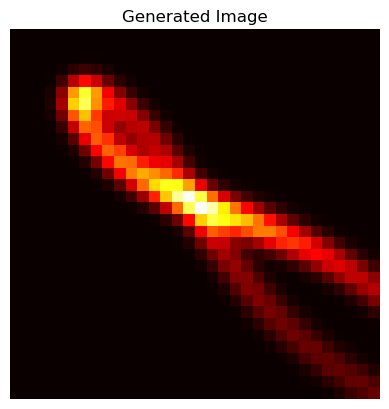

In [4]:
plt.figure()
plt.imshow(gen_img.reshape(32, 32).cpu(), cmap = "hot")
plt.title("Generated Image")
plt.axis("off")
plt.show()

---
## Loss Landscape Visualization
---
In this section, we explore and visualize the **shape of the loss surfaces** for:

- **Parameter error** (how well the network predicts the true orbital parameters).
- **Physical consistency error** (image reconstruction error from predicted parameters).

By plotting these landscapes as **contour maps**, we can:

✅ Understand how the model training behaves across different regions of the parameter space (eccentricity and inclination).  
✅ Check the sensitivity and stability of the error to small parameter variations.  

Randomly sampled points are also highlighted to illustrate concrete examples tested individually.

This analysis provides valuable insights into the **robustness** and **generalization** capacity the training model framework, as well as its adherence to physical constraints.


In [30]:

mse = torch.nn.MSELoss()

# Choose reference orbit parameters
orbit_ref = torch.zeros(1, 1, 3)
orbit_ref[:, 0, 0] = 0.5                          # eccentricity
orbit_ref[:, 0, 1] = np.deg2rad(45)              # inclination
orbit_ref[:, 0, 2] = np.deg2rad(9)               # argument of perigee

# Generate image from reference parameters
img_from_ref = gen(orbit_ref)

# Define parameter grid
ecc_range = torch.linspace(0, 0.9, 60)                          # eccentricity range
inc_range = torch.linspace(0, np.deg2rad(80), 60)              # inclination range

error_param_map = torch.zeros(len(ecc_range), len(inc_range))
error_img_map = torch.zeros(len(ecc_range), len(inc_range))

# Evaluate error for each (eccentricity, inclination) pair
for i, ecc in enumerate(ecc_range):
    for j, inc in enumerate(inc_range):
        # Build test orbit with varying ecc and inc, keep argper fixed
        orbit_test = torch.zeros(1, 1, 3)
        orbit_test[:, 0, 0] = ecc
        orbit_test[:, 0, 1] = inc
        orbit_test[:, 0, 2] = orbit_ref[:, 0, 2]  # keep argument of perigee fixed

        # Generate image from these orbit parameters
        img_test = gen(orbit_test)        # Compute parameter error (MSE on parameters)
        param_error = mse(orbit_test.view(1, -1), orbit_ref.view(1, -1)).item()



        # Compute image error (MSE on images)
        img_error = mse(img_test.view(1, -1), img_from_ref.view(1, -1)).item()

        # Store errors in maps
        error_param_map[i, j] = param_error
        error_img_map[i, j] = img_error

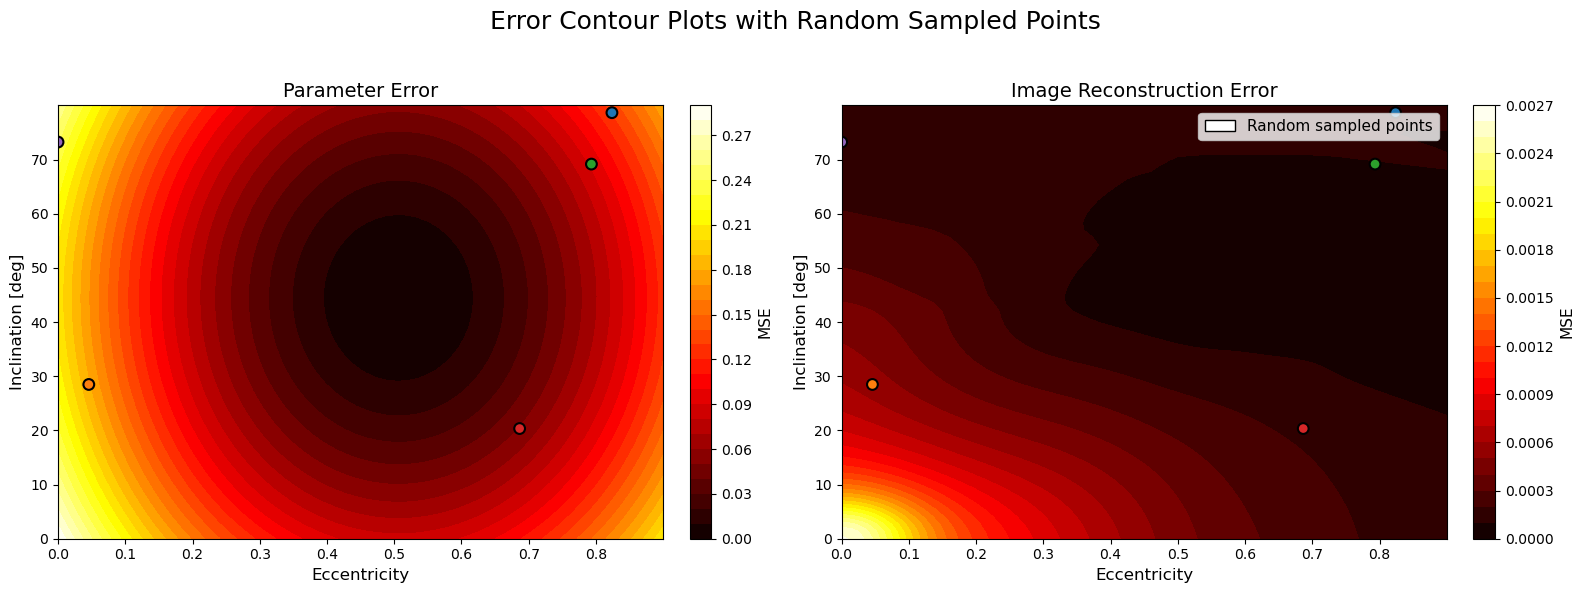

In [54]:


# Generate 5 (almost random) test points from the grid
num_points = 5
cmap = plt.get_cmap("tab10")  
colors = [cmap(i % cmap.N) for i in range(num_points)]


selected_indices = []

while len(selected_indices) < num_points:
    i = random.randint(0, len(ecc_range) - 1)
    j = random.randint(0, len(inc_range) - 1)
    if (i, j) not in selected_indices:
        selected_indices.append((i, j))

# Convert indices to eccentricity and inclination values for plotting
selected_ecc = [ecc_range[i].item() for i, j in selected_indices]
selected_inc = [np.rad2deg(inc_range[j].item()) for i, j in selected_indices]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create grid for contour plots
ecc_grid, inc_grid = torch.meshgrid(ecc_range, inc_range, indexing="ij")
ecc_grid_np = ecc_grid.numpy()
inc_grid_deg = np.rad2deg(inc_grid.numpy())

# --- Parameter Error Contour Plot ---
ax = axes[0]
cs1 = ax.contourf(ecc_grid_np, inc_grid_deg, error_param_map.numpy().T, levels=30, cmap="hot")
ax.scatter(selected_ecc, selected_inc, color=colors, marker="o", s=60, edgecolors="black", linewidths=1.5)
ax.set_xlabel("Eccentricity", fontsize=12)
ax.set_ylabel("Inclination [deg]", fontsize=12)
ax.set_title("Parameter Error", fontsize=14)
cbar1 = plt.colorbar(cs1, ax=ax, fraction=0.046, pad=0.04)
cbar1.set_label("MSE", fontsize=11)

# --- Image Error Contour Plot ---
ax = axes[1]
cs2 = ax.contourf(ecc_grid_np, inc_grid_deg, error_img_map.numpy().T, levels=30, cmap="hot")
ax.scatter(selected_ecc, selected_inc, color=colors, marker="o", s=60, edgecolors="black", linewidths=1.5)
ax.set_xlabel("Eccentricity", fontsize=12)
ax.set_ylabel("Inclination [deg]", fontsize=12)
ax.set_title("Image Reconstruction Error", fontsize=14)
cbar2 = plt.colorbar(cs2, ax=ax, fraction=0.046, pad=0.04)
cbar2.set_label("MSE", fontsize=11)

# Add custom legend
point_patch = mpatches.Patch(facecolor="white", edgecolor="black", label="Random sampled points")
ax.legend(handles=[point_patch], loc='upper right', fontsize=11, frameon=True)

plt.suptitle("Error Contour Plots with Random Sampled Points", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



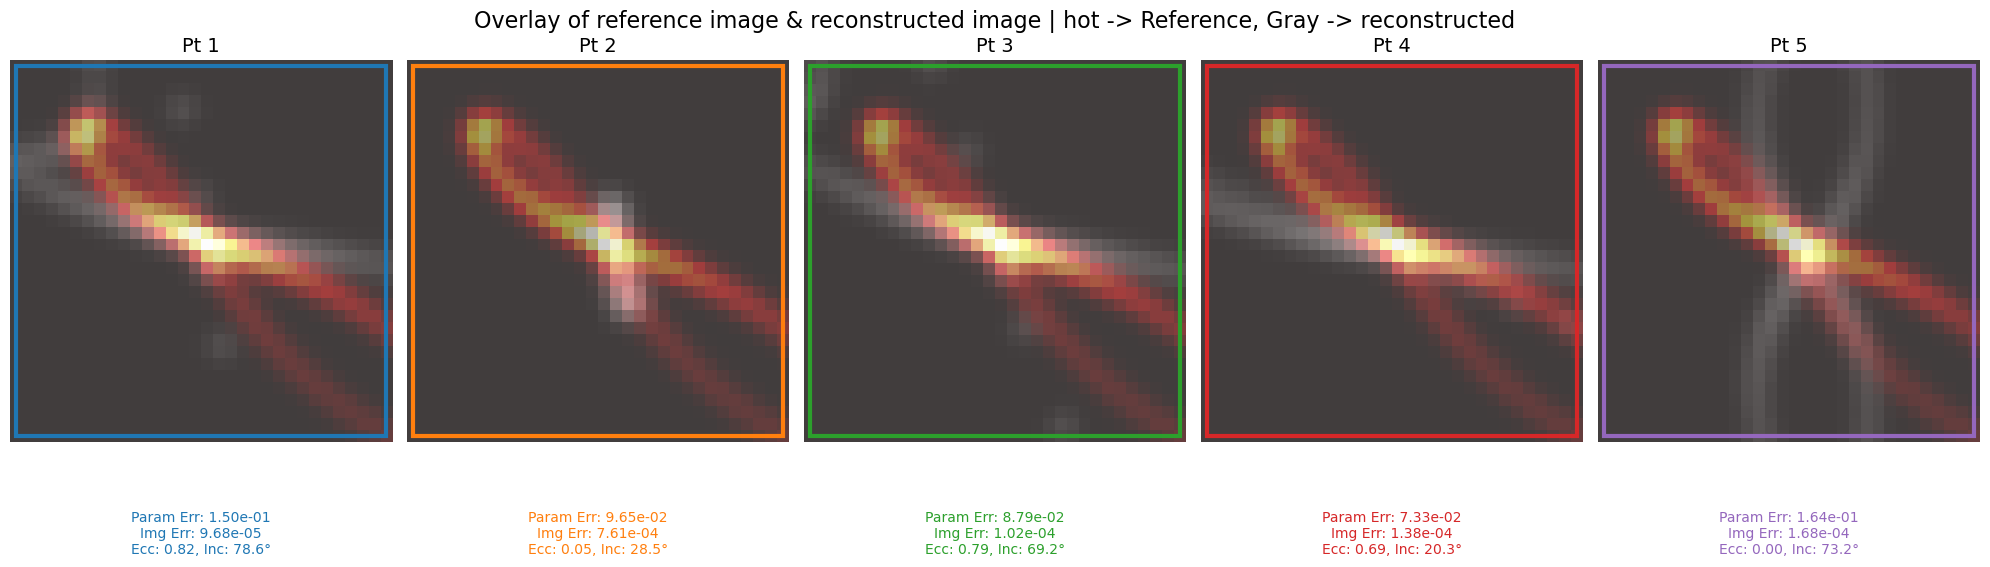

In [55]:


fig, axes = plt.subplots(1, num_points, figsize=(4 * num_points, 5))

for idx, (i, j) in enumerate(selected_indices):
    ecc = ecc_range[i]
    inc = inc_range[j]

    # Build test orbit
    orbit_test = torch.zeros(1, 1, 3)
    orbit_test[:, 0, 0] = ecc
    orbit_test[:, 0, 1] = inc
    orbit_test[:, 0, 2] = orbit_ref[:, 0, 2]

    # Generate image
    img_test = gen(orbit_test)


    # Compute errors
    img_error = mse(img_test.view(1, -1), img_from_ref.view(1, -1)).item()
    param_error = mse(orbit_test.view(1, -1), orbit_ref.view(1, -1)).item()

    ax = axes[idx]

    # Display reference image
    ax.imshow(img_test.reshape(32, 32).detach().cpu(), cmap="gray", alpha=0.6)
    # Overlay predicted image
    ax.imshow(img_from_ref.reshape(32, 32).detach().cpu(), cmap="hot", alpha=0.4)

    # Remove ticks
    ax.axis("off")
    ax.set_title(f"Pt {idx+1}", fontsize=14)

    # Add colored rectangle contour on the image
    rect = mpatches.Rectangle(
        (0, 0),                # Bottom-left corner
        31,                    # Width
        31,                    # Height
        linewidth=3,
        edgecolor=colors[idx],
        facecolor='none'
    )
    ax.add_patch(rect)

    # Add text below
    ax.text(
        0.5, -0.18,
        f"Param Err: {param_error:.2e}\nImg Err: {img_error:.2e}\nEcc: {ecc:.2f}, Inc: {np.rad2deg(inc):.1f}°",
        size=10,
        ha="center",
        va="top",
        transform=ax.transAxes,
        color=colors[idx]
    )

plt.suptitle("Overlay of reference image & reconstructed image | hot -> Reference, Gray -> reconstructed", fontsize=16)
plt.tight_layout()
plt.show()

###  Combined Error Landscapes Across Different λ Values

In this figure, we visualize how the **combined error landscape** evolves as we vary the weighting parameter λ.

We define the **combined error** at each point as:

$$
\text{Combined Error} = \lambda \times \text{Image Error} + (1 - \lambda) \times \text{Parameter Error}
$$

where:

- **Image Error** encourages physical consistency by minimizing the difference between the true and reconstructed images.
- **Parameter Error** focuses on accurately recovering the true orbital parameters.

By adjusting λ from 0 to 1, we control the trade-off between these two objectives:

- **λ = 0**: purely parameter accuracy, no image consistency.
- **λ = 1**: purely physical (image) consistency, ignoring parameter accuracy.
- **Intermediate λ values** provide a balance between the two.


Each subplot corresponds to a different λ value, highlighting the progressive deformation of the error surface.


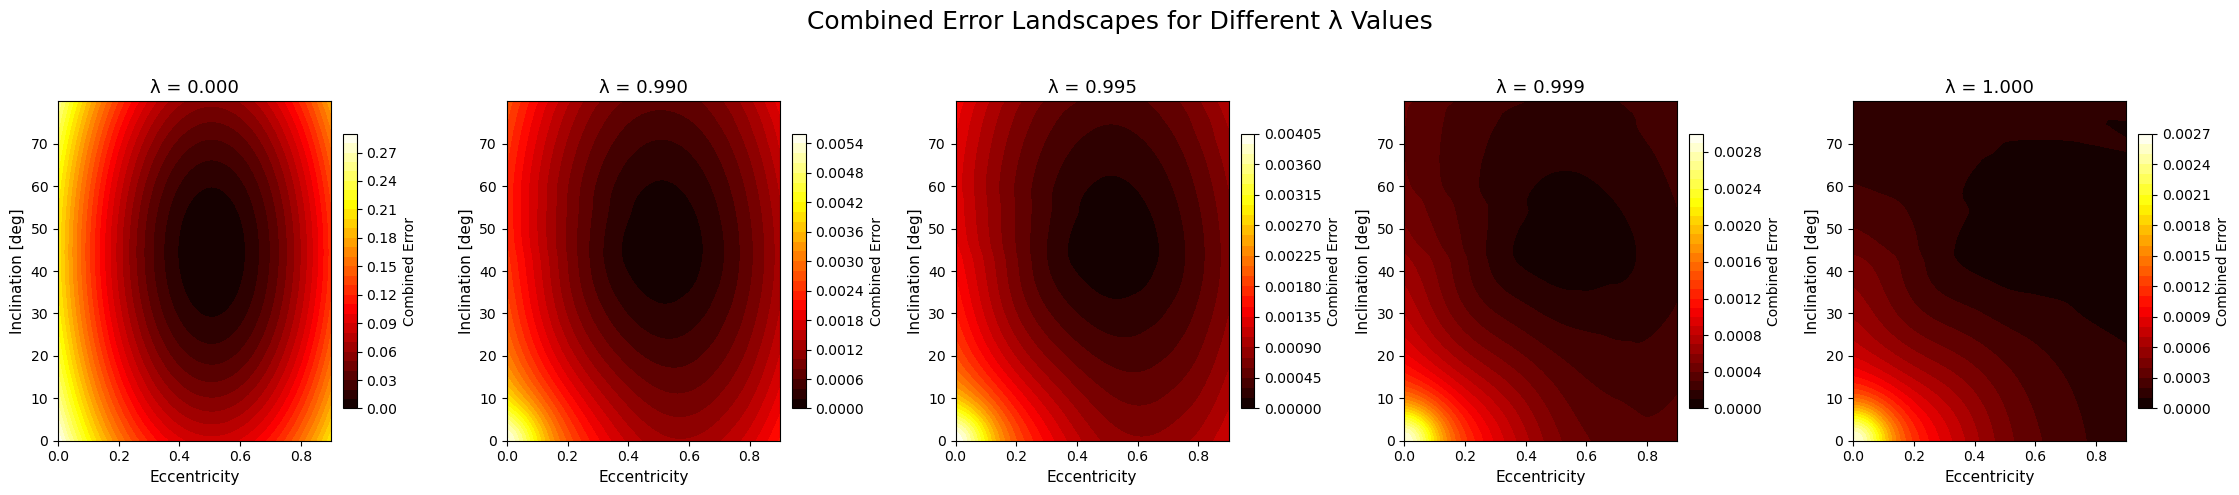

In [56]:
lambdas = [0,0.99, 0.995, 0.999, 1.0]
num_lambdas = len(lambdas)

fig, axes = plt.subplots(1, num_lambdas, figsize=(4.5 * num_lambdas, 5))

# Create meshgrid for contour
ecc_grid, inc_grid = torch.meshgrid(ecc_range, inc_range, indexing="ij")
ecc_grid_np = ecc_grid.numpy()
inc_grid_deg = np.rad2deg(inc_grid.numpy())

for idx, lambda_ in enumerate(lambdas):
    ax = axes[idx]
    
    # Combine error maps
    combined_map = lambda_ * error_img_map + (1 - lambda_) * error_param_map
    combined_np = combined_map.numpy().T
    
    # Contour plot
    cs = ax.contourf(ecc_grid_np, inc_grid_deg, combined_np, levels=30, cmap="hot")
    ax.set_xlabel("Eccentricity", fontsize=11)
    ax.set_ylabel("Inclination [deg]", fontsize=11)
    ax.set_title(f"λ = {lambda_:.3f}", fontsize=13)
    
    # Add colorbar per subplot
    cbar = plt.colorbar(cs, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Combined Error", fontsize=10)

plt.suptitle("Combined Error Landscapes for Different λ Values", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


---
## Dataset generation
---

### Example of Generated Images

Let’s now display a few generated samples from the training set to visually inspect their diversity and quality.


In [272]:
# Number of samples for training and testing
K_train = 100
K_test = 1_000

# Image size (generator output resolution)
img_size = 32

# Initialize generator on CPU
gen = decoder.decoder(img_size, "cpu")

def gen_dataset(num_samples):
    """
    Generate a dataset of images and corresponding orbital parameters.
    
    Args:
        num_samples (int): Number of samples to generate.
        
    Returns:
        orbit (torch.Tensor): Generated orbital parameters, shape [num_samples, 1, 3].
        gen_img (torch.Tensor): Generated images, shape [num_samples, 1, img_size, img_size].
    """
    orbit = torch.zeros(num_samples, 1, 3)

    # Altitude (or parameter 1): uniform in [0, 0.6]
    orbit[:, 0, 0] = torch.rand(num_samples) * 0.6
    
    # Inclination (or parameter 2): uniform in [0°, 45°]
    orbit[:, 0, 1] = torch.deg2rad(torch.rand(num_samples) * 45)
    
    # Argument of perigee (or parameter 3): uniform in [-15°, 15°]
    orbit[:, 0, 2] = torch.deg2rad(torch.rand(num_samples) * 30 - 15)

    # Generate images from parameters
    gen_img = gen(orbit)
    
    return orbit, gen_img

# Generate test and training datasets
orbit_test, gen_img_test = gen_dataset(K_test)
orbit_train, gen_img_train = gen_dataset(K_train)


### Creating PyTorch Datasets

Now that we have generated our images and corresponding orbital parameters,  
we can wrap them into `TensorDataset` objects from PyTorch.  

This allows us to easily use them with data loaders for training and evaluation.

- `dataset_train`: contains the training images and orbital parameters.
- `dataset_test`: contains the test images and orbital parameters.

In [273]:
dataset_test = TensorDataset(gen_img_test, orbit_test)
dataset_train = TensorDataset(gen_img_train, orbit_train)

### Creating DataLoaders

We now create `DataLoader` objects to efficiently iterate over our datasets during training and testing.  

- `loader_train`: shuffles the training data to improve generalization.
- `loader_test`: does not shuffle to keep the test order consistent.

We use a batch size of 10 in this example, but this can be adjusted depending on your memory and convergence needs.


In [274]:
loader_train = DataLoader(dataset_train, batch_size=10, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=10, shuffle=False)

---
## Training and Evaluation Loop
---
We define a function to perform a single epoch, which can be used for both training and evaluation.  

This function computes two losses:

- **Label loss (`l_label`)**: measures the error between predicted orbital parameters and the true labels.
- **Physics loss (`l_physics`)**: compares the image reconstructed from predicted parameters to the original image.  

A weighted combination of both losses is used, controlled by the hyperparameter **λ** (`lambda_`).  

When `train=True`, the function updates the network parameters using backpropagation.

In [275]:


def single_epoch(net, lr, lambda_, dataloader, optimizer, train=True, device="cpu"):
    """
    Performs one epoch of training or evaluation.

    Args:
        lr (float): Learning rate (not used directly here since the optimizer has it).
        dataloader (DataLoader): DataLoader for training or testing.
        optimizer (torch.optim.Optimizer): Optimizer.
        train (bool): Whether to update the model parameters.
        device (str): Device ("cpu" or "cuda").
        
    Returns:
        l_label_item (float): Average label loss over the epoch.
        l_physics_item (float): Average physics loss over the epoch.
    """
    l_label_item = 0.0
    l_physics_item = 0.0

    for img, orbit_label in dataloader:
        img = img.to(device)
        orbit_label = orbit_label.to(device)

        # Predict orbital parameters from image
        orbit_pred = net(img)
        
        # Split predicted parameters
        ecc = orbit_pred[:, 0]
        inc = orbit_pred[:, 1]
        argper = orbit_pred[:, 2]

        # Label loss (predicted vs ground truth orbit parameters)
        l_label = mse(torch.stack((ecc, inc, argper), dim=-1)[:, None, :], orbit_label)
       
        # Generate image from predicted parameters
        pred_orbit_clamped = torch.stack((torch.clamp(ecc, 0, 0.5), inc, argper), dim=-1)[:, None, :]
        img_from_pred = gen(pred_orbit_clamped).to(device)

        # Physics loss (reconstructed image vs original)
        l_physics = mse(img_from_pred, img)
        
        # Combined loss
        l = lambda_ * l_label + (1 - lambda_) * l_physics

        # Accumulate average losses
        l_label_item += l_label.item() / len(dataloader)
        l_physics_item += l_physics.item() / len(dataloader)

        if train:
            optimizer.zero_grad()
            l.backward()
            optimizer.step()

    return l_label_item, l_physics_item


## Training Loop

We now define a function to handle the full training and evaluation loop over multiple epochs.

Key features:

- Uses separate **label loss** and **physics loss** to track model performance.
- Supports resuming from a specific epoch using the `start` argument.
- Optionally displays progress bars for epochs and batches using `tqdm`.
- Saves training and test losses for later visualization.
- Optional checkpoint saving code is included (commented out).

This function calls `single_epoch()` internally for both training and test sets at each epoch.

In [276]:
# Dictionaries to store loss histories
loss_label = {"test": [], "train": []}
loss_physics = {"test": [], "train": []}

def train(net, nbr_iter=100, lr=0.001, lambda_ = 0.5 , progressbar=True, start=0, log = True):
    """
    Train and evaluate the network over multiple epochs.

    Args:
        net (nn.Module): The neural network to train.
        nbr_iter (int): Number of epochs.
        lr (float): Learning rate.
        progressbar (bool): Whether to display a tqdm progress bar.
        start (int): Starting epoch index (for resuming training).

    Returns:
        None (updates global loss_label and loss_physics dictionaries).
    """
    net = net.to(device)

    # Create epoch loop
    if progressbar:
        loop_obj = tqdm(range(start, nbr_iter), desc="Epochs")
    else:
        loop_obj = range(start, nbr_iter)

    # Define optimizer
    optimizer = optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.99))

    for e in loop_obj:
        t_start_epoch = time.time()

        # Training epoch
        l_label_train, l_physics_train = single_epoch(net, lr, lambda_, tqdm(loader_train, leave=False), optimizer, train=True, device=device)
        loss_label["train"].append(l_label_train)
        loss_physics["train"].append(l_physics_train)

        # Evaluation epoch
        l_label_test, l_physics_test = single_epoch(net, lr, lambda_, tqdm(loader_test, leave=False), optimizer, train=False, device=device)
        loss_label["test"].append(l_label_test)
        loss_physics["test"].append(l_physics_test)
        if log:
            # Print summary
            print(f"Epoch {e + 1} duration: {(time.time() - t_start_epoch) / 60:.2f} minutes")
            print("----- Loss function values -------")
            print(f"Train set  -> Loss_parameters: {l_label_train:.6f}  |  Loss_physics: {l_physics_train:.6f}")
            print(f"Test set   -> Loss_parameters: {l_label_test:.6f}  |  Loss_physics: {l_physics_test:.6f}")

        # Optional: Save model checkpoint
        # torch.save({
        #     'epoch': e,
        #     'model_state_dict': net.state_dict(),
        #     'optimizer_state_dict': optimizer.state_dict(),
        #     'loss_label_train': l_label_train,
        #     'loss_label_test': l_label_test,
        #     'learning_rate': lr
        # }, f"model_{e}.pth")


## Defining the Neural Network

We define a simple **fully-connected neural network** (MLP) to predict orbital parameters from the generated images.

Architecture:

- **Input layer**: flattened image vector (`img_size²` features).
- **Hidden layers**: three layers with 24 units each and ReLU activations.
- **Output layer**: 3 neurons to predict eccentricity, inclination, and argument of perigee.

This simple model is used as a proof of concept before trying more advanced architectures (e.g., convolutional networks).

In [277]:
# Define a simple fully-connected neural network to predict orbit parameters from images
net = torch.nn.Sequential(
    nn.Linear(img_size**2, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 3)  # Output: [eccentricity, inclination, argument of perigee]
)


### Launching Training

We now set the computation device to GPU if available (using `"cuda:0"`), otherwise fallback to CPU.  

We then launch the training loop:

- **Number of epochs**: 100
- **Learning rate**: 0.0001
- **Progress bar**: disabled for simpler console output (can be set to `True` for interactive visualization)

After this step, the model will iteratively minimize the losses and learn to predict orbital parameters from images.

In [278]:
# Launch training
train(net, nbr_iter=15, lr=0.01, lambda_ = 0.99, progressbar=False)

Epoch 1 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.061999  |  Loss_physics: 0.000695
Test set   -> Loss_parameters: 0.035705  |  Loss_physics: 0.000606


Epoch 2 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.030611  |  Loss_physics: 0.000618
Test set   -> Loss_parameters: 0.022092  |  Loss_physics: 0.000526


Epoch 3 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.021763  |  Loss_physics: 0.000518
Test set   -> Loss_parameters: 0.019784  |  Loss_physics: 0.000477


Epoch 4 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.016988  |  Loss_physics: 0.000454
Test set   -> Loss_parameters: 0.014781  |  Loss_physics: 0.000385


Epoch 5 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.011336  |  Loss_physics: 0.000347
Test set   -> Loss_parameters: 0.009746  |  Loss_physics: 0.000286


...

Epoch 11 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.001101  |  Loss_physics: 0.000053
Test set   -> Loss_parameters: 0.001755  |  Loss_physics: 0.000074


Epoch 12 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.000770  |  Loss_physics: 0.000039
Test set   -> Loss_parameters: 0.001495  |  Loss_physics: 0.000065


Epoch 13 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.000589  |  Loss_physics: 0.000031
Test set   -> Loss_parameters: 0.001299  |  Loss_physics: 0.000054


Epoch 14 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.000455  |  Loss_physics: 0.000025
Test set   -> Loss_parameters: 0.001273  |  Loss_physics: 0.000051


Epoch 15 duration: 0.02 minutes
----- Loss function values -------
Train set  -> Loss_parameters: 0.000449  |  Loss_physics: 0.000026
Test set   -> Loss_parameters: 0.001216  |  Loss_physics: 0.000055


---
## Testing the Generator with New Orbit Parameters
---
We now create a **new orbit example** to test the generator and see how well it produces an image from unseen parameters.

- **Eccentricity**: 0.4
- **Inclination**: 2° (converted to radians)
- **Argument of perigee**: 9° (converted to radians)

We then use the trained generator to create a synthetic image corresponding to this orbit configuration.

In [287]:
# Create a specific test orbit (example parameters)
orbit = torch.zeros(1, 1, 3)

orbit[:, 0, 0] = 0.6                       # Eccentricity (or similar parameter)
orbit[:, 0, 1] = np.deg2rad(20)            # Inclination in radians
orbit[:, 0, 2] = np.deg2rad(9)            # Argument of perigee in radians

# Generate image from these orbit parameters
gen_img = gen(orbit)

### Predicting Orbit Parameters from Generated Image

We now pass the **generated image** through our trained neural network to predict the orbit parameters.

Steps:

- Flatten the image to match the input shape expected by the network.
- Move the image to GPU (`"cuda:0"`) before inference.

The network outputs predicted values for eccentricity, inclination, and argument of perigee.

In [288]:
res = net(gen_img.to("cuda:0"))

In [289]:
# Move prediction back to CPU for comparison
res_cpu = res.cpu()

# Compute mean squared error between true parameters and predicted parameters
error_mse = mse(orbit.view(1, -1), res_cpu.view(1, -1)).item()

print(f"🔎 MSE error between true orbit and prediction: {error_mse:.6f}\n")

print("🚀 Predicted orbit parameters (network output):")
print(res_cpu)

print("\n✅ True orbit parameters:")
print(orbit)

🔎 MSE error between true orbit and prediction: 0.001687

🚀 Predicted orbit parameters (network output):
tensor([[0.5422, 0.3445, 0.1159]], grad_fn=<ToCopyBackward0>)

✅ True orbit parameters:
tensor([[[0.6000, 0.3491, 0.1571]]])


### Visual Comparison: True Image vs Predicted Image

We now compare the **original image generated from true orbit parameters** and the **image generated from the parameters predicted by the network**.

This visual comparison helps us assess if the network's predicted orbit parameters are meaningful and consistent when used to regenerate an image.


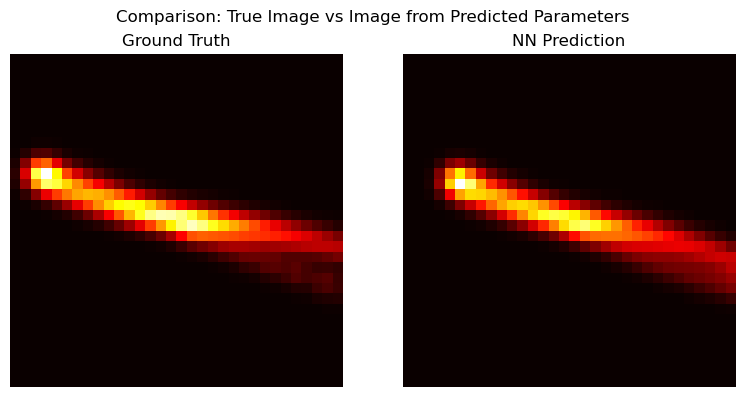

In [290]:
# Generate image from predicted orbit parameters
gen_img_from_nn = gen(res[:, None, :])

# Create figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Original generated image (ground truth)
ax[0].imshow(gen_img.reshape(32, 32).detach().cpu(), cmap = "hot")
ax[0].set_title("Ground Truth")
ax[0].axis("off")

# Image generated from predicted parameters
ax[1].imshow(gen_img_from_nn.reshape(32, 32).detach().cpu(), cmap = "hot")
ax[1].set_title("NN Prediction")
ax[1].axis("off")

plt.suptitle("Comparison: True Image vs Image from Predicted Parameters", fontsize=12)
plt.tight_layout()
plt.show()

---
##  Testing Different λ Values and Visualizing Error Landscapes
---
In this section, we experiment with training the network using **different values of λ (lambda)**.  
The λ parameter controls the trade-off between two losses:

- **Parameter loss** (orbit parameter prediction accuracy).
- **Physics loss** (image reconstruction consistency).

We train one network for each λ value to explore how this weighting affects model behavior.

After training, we visualize the **error landscapes** across the parameter space.  
This allows us to:

✅ Understand how each λ shapes the loss surface.  
✅ See the impact of prioritizing physical consistency versus parameter accuracy.  
✅ Assess model robustness and generalization under different loss combinations.

Finally, we compare these landscapes side by side to clearly illustrate the effect of λ on the error distribution.


In [254]:
# lambda_values = [0.5,0.01,0.005,0.]
# lambda_values = [1.,0.5,0.02,0.01,0.005,0.0001,0.]
lambda_values = [0.1,0.01,0.001,0.]

# Define a simple fully-connected neural network to predict orbit parameters from images
net = torch.nn.Sequential(
    nn.Linear(img_size**2, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 3)  # Output: [eccentricity, inclination, argument of perigee]
).to("cpu")



nets = [copy.deepcopy(net) for _ in range(len(lambda_values))]

for i in range(len(lambda_values)):
    train(nets[i], nbr_iter=30, lr=0.01, lambda_ = lambda_values[i], progressbar=False , log = False)

In [255]:
mse = torch.nn.MSELoss()


# Define parameter grid
ecc_range = torch.linspace(0, 0.8, 30)                         # eccentricity range
inc_range = torch.linspace(0, np.deg2rad(60), 30)              # inclination range

error_param_map = torch.zeros(len(lambda_values), len(ecc_range), len(inc_range))
error_img_map = torch.zeros(len(lambda_values), len(ecc_range), len(inc_range))

# Evaluate error for each (eccentricity, inclination) pair
for k, l in enumerate(lambda_values):
    for i, ecc in enumerate(ecc_range):
        for j, inc in enumerate(inc_range):
            # Build test orbit with varying ecc and inc, keep argper fixed
            orbit_test = torch.zeros(1, 1, 3)
            orbit_test[:, 0, 0] = ecc
            orbit_test[:, 0, 1] = inc
            orbit_test[:, 0, 2] =  np.deg2rad(9)  
            # Generate image from these orbit parameters
            img_test = gen(orbit_test)        # Compute parameter error (MSE on parameters)

            orbit_rebuild = nets[k](img_test.to("cuda:0")).cpu()
    
            img_from_nn = gen(orbit_rebuild[None,...])
            
            param_error = mse(orbit_test.view(1, -1), orbit_rebuild.view(1, -1)).item()
            # Compute image error (MSE on images)
            img_error = mse(img_test.view(1, -1), img_from_nn.view(1, -1)).item()
    
            # Store errors in maps
            error_param_map[k, i, j] = param_error
            error_img_map[k, i, j] = img_error

###  Visualizing Error Landscapes for Different λ Values

Here, we visualize how the **parameter error** and **image reconstruction error** landscapes evolve as we vary λ.

For each λ value:

- The **left column** shows the parameter error surface, reflecting how accurately the model recovers orbital parameters.
- The **right column** shows the image reconstruction error surface, highlighting physical consistency.

These contour plots allow us to:

✅ Understand the trade-off induced by λ between accurate parameter prediction and physical image consistency.  
✅ Identify different error minima and see how valleys shift when λ changes.  
✅ Evaluate the robustness and behavior of the learned model across the parameter space.

Each row corresponds to a different λ value, helping us clearly compare their impact on both error types.


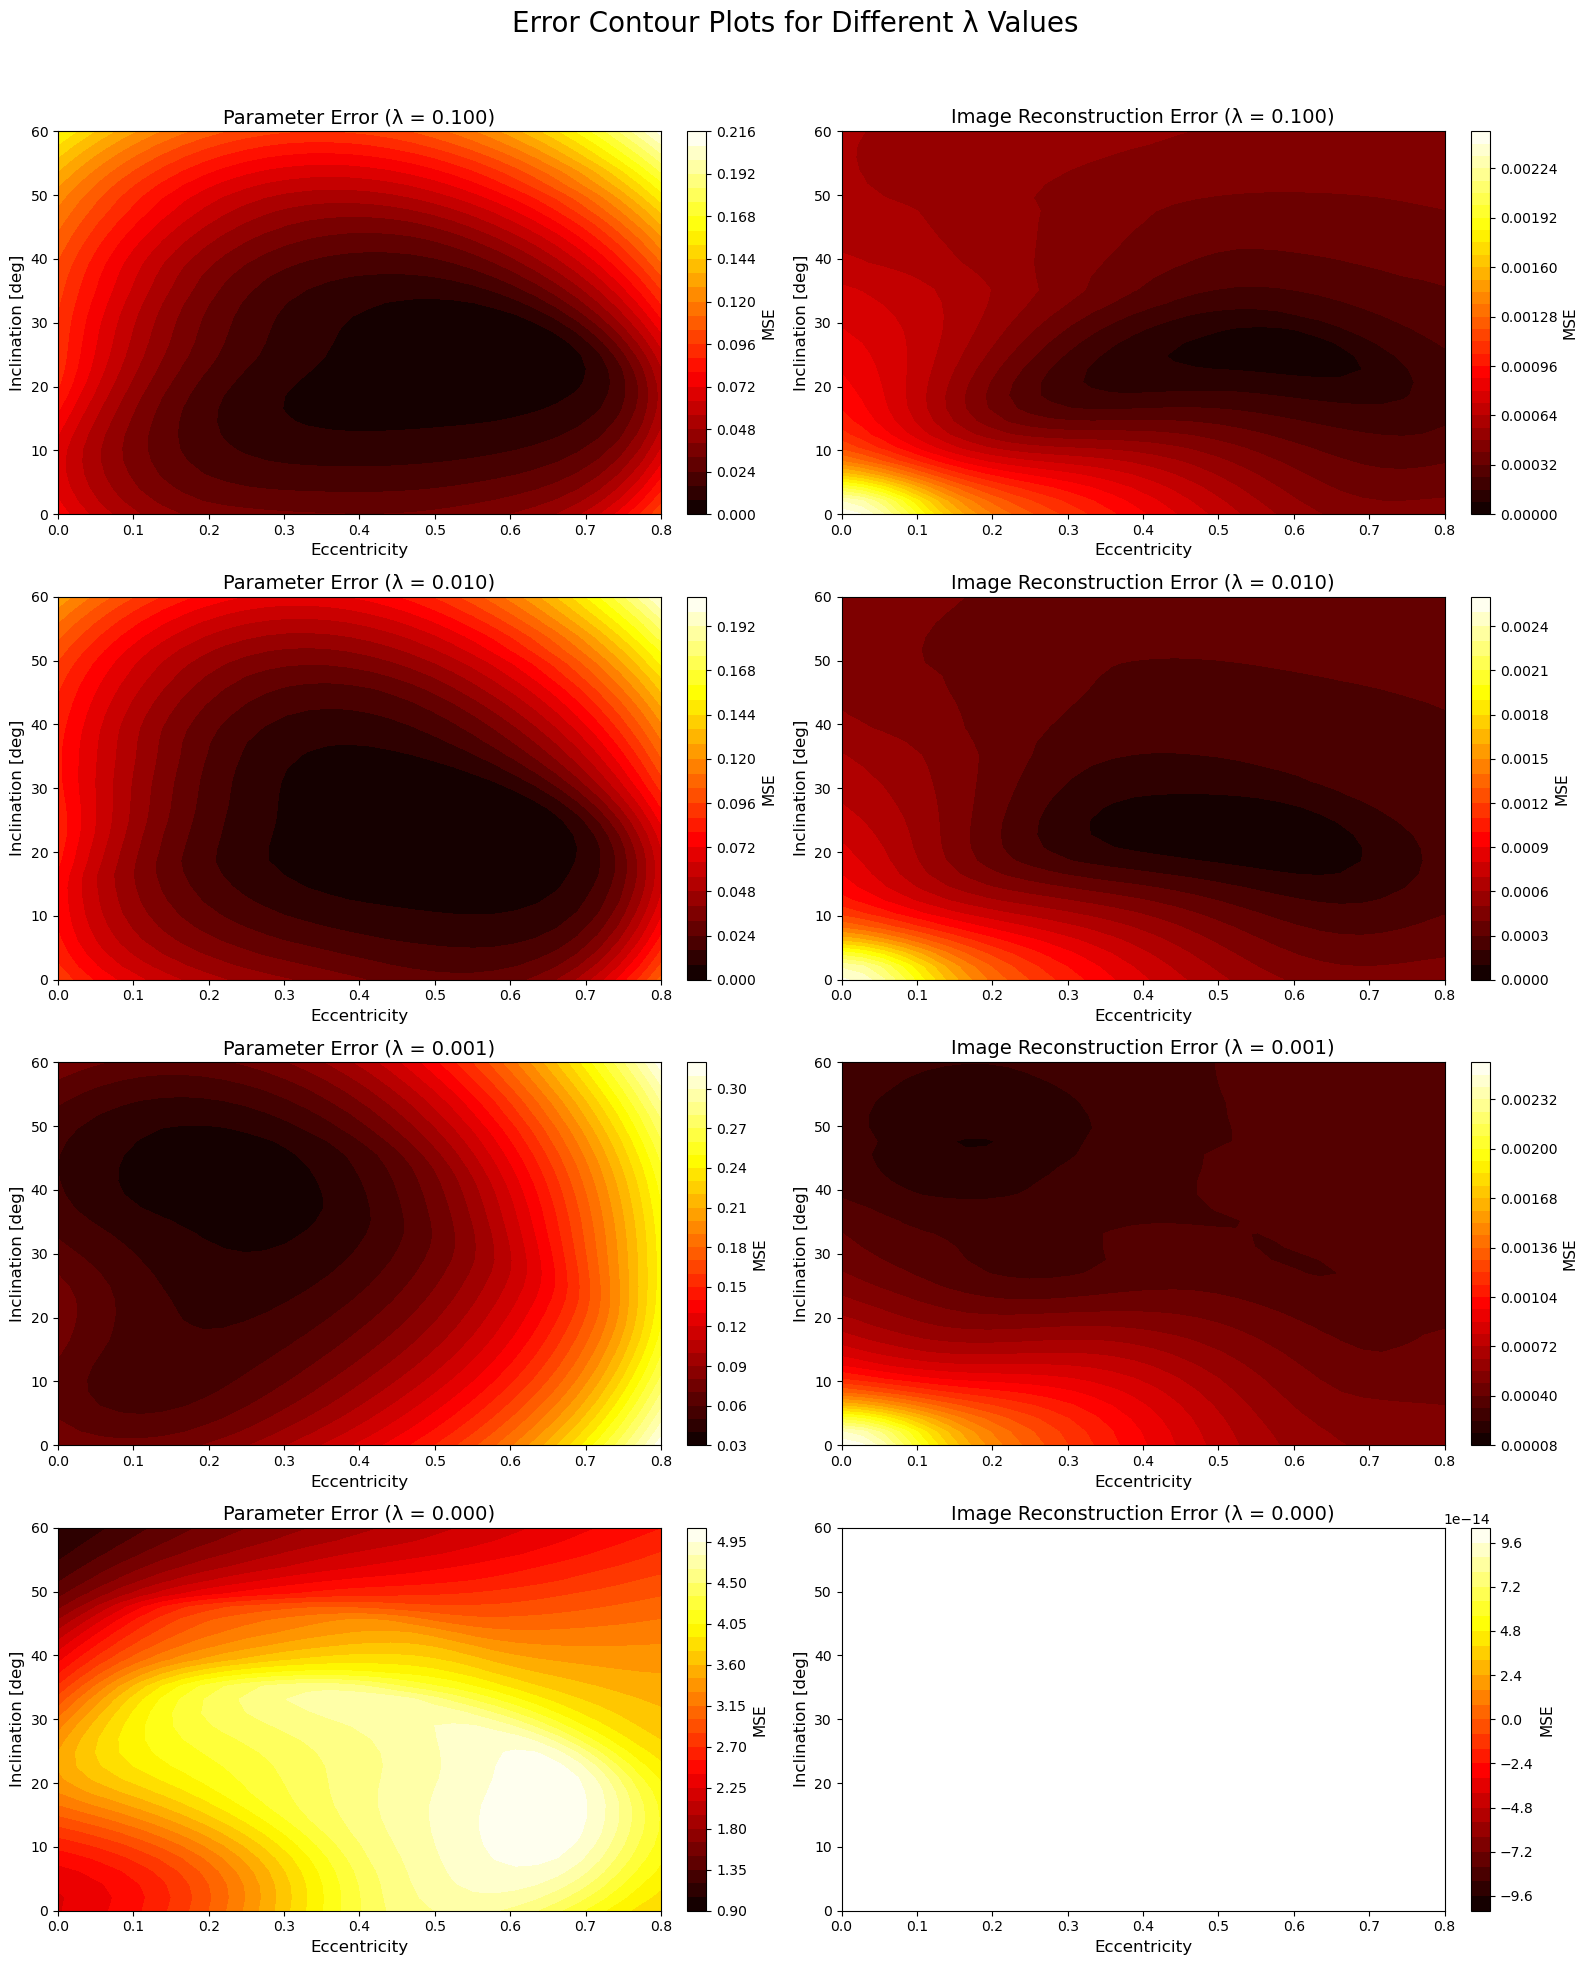

In [259]:
fig, axes = plt.subplots(len(lambda_values), 2, figsize=(16, 5 * len(lambda_values)))

# Create grid for contour plots
ecc_grid, inc_grid = torch.meshgrid(ecc_range, inc_range, indexing="ij")
ecc_grid_np = ecc_grid.numpy()
inc_grid_deg = np.rad2deg(inc_grid.numpy())

# Compute global min/max for consistent color scaling
vmin_param = min([error_param_map[k].min().item() for k in range(len(lambda_values))])
vmax_param = max([error_param_map[k].max().item() for k in range(len(lambda_values))])

vmin_img = min([error_img_map[k].min().item() for k in range(len(lambda_values))])
vmax_img = max([error_img_map[k].max().item() for k in range(len(lambda_values))])

for k, l in enumerate(lambda_values):
    # --- Parameter Error Contour Plot ---
    ax = axes[k, 0]
    cs1 = ax.contourf(
        ecc_grid_np, inc_grid_deg, error_param_map[k].numpy().T,
        levels=30, cmap="hot")
        # , vmin=vmin_param, vmax=vmax_param)
    
    ax.set_xlabel("Eccentricity", fontsize=12)
    ax.set_ylabel("Inclination [deg]", fontsize=12)
    ax.set_title(f"Parameter Error (λ = {l:.3f})", fontsize=14)
    cbar1 = plt.colorbar(cs1, ax=ax, fraction=0.046, pad=0.04)
    cbar1.set_label("MSE", fontsize=11)
    
    # --- Image Error Contour Plot ---
    ax = axes[k, 1]
    cs2 = ax.contourf(
        ecc_grid_np, inc_grid_deg, error_img_map[k].numpy().T,
        levels=30, cmap="hot")
        # , vmin=vmin_img, vmax=vmax_img)


    
    ax.set_xlabel("Eccentricity", fontsize=12)
    ax.set_ylabel("Inclination [deg]", fontsize=12)
    ax.set_title(f"Image Reconstruction Error (λ = {l:.3f})", fontsize=14)
    cbar2 = plt.colorbar(cs2, ax=ax, fraction=0.046, pad=0.04)
    cbar2.set_label("MSE", fontsize=11)

plt.suptitle("Error Contour Plots for Different λ Values", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
